In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

print(os.getenv("DB_USER"))
print(os.getenv("DB_HOST"))
print(os.getenv("DB_NAME"))

postgres
localhost
ravenstack


In [2]:
import os
import urllib.parse
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()

def get_engine():
    password = urllib.parse.quote_plus(os.getenv("DB_PASSWORD"))
    user = os.getenv("DB_USER")
    host = os.getenv("DB_HOST")
    port = os.getenv("DB_PORT")
    dbname = os.getenv("DB_NAME")

    connection_string = (
        f"postgresql://{user}:{password}@{host}:{port}/{dbname}"
    )

    return create_engine(connection_string)

In [7]:
pip install python-dotenv

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

engine = get_engine()

tables = pd.read_sql("""
SELECT table_name
FROM information_schema.tables
WHERE table_schema='public'
""", engine)

tables

,table_name
0,subscriptions
1,churn_events
2,accounts
3,support_tickets
4,feature_usage


In [4]:
import pandas as pd

# Why a dictionary instead of 5 separate variables (accounts, subs, etc.)?
# It lets us loop over all tables for repeated checks (shape, dtypes, nulls)
# instead of copy-pasting the same code 5 times. DRY principle.
table_names = ['accounts', 'subscriptions', 'feature_usage', 'support_tickets', 'churn_events']

dataframes = {}
for table in table_names:
    dataframes[table] = pd.read_sql(f'SELECT * FROM {table}', engine)
    print(f"Loaded '{table}': {dataframes[table].shape[0]} rows, {dataframes[table].shape[1]} columns")

# Unpack into named variables for convenience when working with one table at a time
accounts = dataframes['accounts']
subscriptions = dataframes['subscriptions']
feature_usage = dataframes['feature_usage']
support_tickets = dataframes['support_tickets']
churn_events = dataframes['churn_events']

Loaded 'accounts': 500 rows, 10 columns
Loaded 'subscriptions': 5000 rows, 14 columns
Loaded 'feature_usage': 25000 rows, 9 columns
Loaded 'support_tickets': 2000 rows, 9 columns
Loaded 'churn_events': 600 rows, 9 columns


In [5]:
# Shape Checks  this is your first sanity check against the data dictionary/README. If accounts should have 500 rows per documentation and you load 480, something went wrong in the PostgreSQL import — better to catch that in 5 seconds now than 3 hours into an analysis.
print("=" * 60)
print("SHAPE SUMMARY")
print("=" * 60)
for name, df in dataframes.items():
    print(f"{name:20s} → {df.shape[0]:>6,} rows × {df.shape[1]:>2} columns")

SHAPE SUMMARY
accounts             →    500 rows × 10 columns
subscriptions        →  5,000 rows × 14 columns
feature_usage        → 25,000 rows ×  9 columns
support_tickets      →  2,000 rows ×  9 columns
churn_events         →    600 rows ×  9 columns


In [6]:
#Data Type Checks
#What to look for specifically: any column that should be a date but shows up as object (string).
for name, df in dataframes.items():
    print(f"\n--- {name} ---")
    print(df.dtypes)




--- accounts ---
account_id         object
account_name       object
industry           object
country            object
signup_date        object
referral_source    object
plan_tier          object
seats               int64
is_trial             bool
churn_flag           bool
dtype: object

--- subscriptions ---
subscription_id       object
account_id            object
start_date            object
end_date              object
plan_tier             object
seats                  int64
mrr_amount           float64
arr_amount           float64
is_trial                bool
upgrade_flag            bool
downgrade_flag          bool
churn_flag              bool
billing_frequency     object
auto_renew_flag         bool
dtype: object

--- feature_usage ---
usage_row_id            int64
usage_id               object
subscription_id        object
usage_date             object
feature_name           object
usage_count             int64
usage_duration_secs     int64
error_count             int64
is

In [7]:
date_columns = {
    'accounts': ['signup_date'],
    'subscriptions': ['start_date', 'end_date'],
    'feature_usage': ['usage_date'],
    'support_tickets': ['submitted_at', 'closed_at'],
    'churn_events': ['churn_date']
}

for table, cols in date_columns.items():
    for col in cols:
        dtype = dataframes[table][col].dtype
        status = "OK" if 'datetime' in str(dtype) else "NEEDS CONVERSION"
        print(f"{table}.{col}: {dtype} [{status}]")

accounts.signup_date: object [NEEDS CONVERSION]
subscriptions.start_date: object [NEEDS CONVERSION]
subscriptions.end_date: object [NEEDS CONVERSION]
feature_usage.usage_date: object [NEEDS CONVERSION]
support_tickets.submitted_at: datetime64[ns] [OK]
support_tickets.closed_at: datetime64[ns] [OK]
churn_events.churn_date: object [NEEDS CONVERSION]


In [8]:
#If any say "NEEDS CONVERSION":
import pandas as pd
import numpy as np

# --- accounts table dates ---
dataframes['accounts']['signup_date'] = pd.to_datetime(dataframes['accounts']['signup_date'], errors='coerce')

# --- subscriptions table dates ---
dataframes['subscriptions']['start_date'] = pd.to_datetime(dataframes['subscriptions']['start_date'], errors='coerce')
dataframes['subscriptions']['end_date'] = pd.to_datetime(dataframes['subscriptions']['end_date'], errors='coerce')

# --- feature_usage table dates ---
dataframes['feature_usage']['usage_date'] = pd.to_datetime(dataframes['feature_usage']['usage_date'], errors='coerce')

# --- support_tickets table dates ---
dataframes['support_tickets']['submitted_at'] = pd.to_datetime(dataframes['support_tickets']['submitted_at'], errors='coerce')
dataframes['support_tickets']['closed_at'] = pd.to_datetime(dataframes['support_tickets']['closed_at'], errors='coerce')

# --- churn_events table dates ---
dataframes['churn_events']['churn_date'] = pd.to_datetime(dataframes['churn_events']['churn_date'], errors='coerce')

In [9]:
#check
date_columns = {
    'accounts': ['signup_date'],
    'subscriptions': ['start_date', 'end_date'],
    'feature_usage': ['usage_date'],
    'support_tickets': ['submitted_at', 'closed_at'],
    'churn_events': ['churn_date']
}

for table, cols in date_columns.items():
    for col in cols:
        dtype = dataframes[table][col].dtype
        status = "OK" if 'datetime' in str(dtype) else "NEEDS CONVERSION"
        print(f"{table}.{col}: {dtype} [{status}]")

accounts.signup_date: datetime64[ns] [OK]
subscriptions.start_date: datetime64[ns] [OK]
subscriptions.end_date: datetime64[ns] [OK]
feature_usage.usage_date: datetime64[ns] [OK]
support_tickets.submitted_at: datetime64[ns] [OK]
support_tickets.closed_at: datetime64[ns] [OK]
churn_events.churn_date: datetime64[ns] [OK]


In [10]:
#Missing Value Analysis

print("=" * 60)
print("MISSING VALUES")
print("=" * 60)
for name, df in dataframes.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]  # only show columns that actually have missing data
    if len(nulls) > 0:
        pct = (nulls / len(df) * 100).round(1)
        summary = pd.DataFrame({'missing_count': nulls, 'missing_pct': pct})
        print(f"\n--- {name} ---")
        print(summary)
    else:
        print(f"\n--- {name}: no missing values ---")

MISSING VALUES

--- accounts: no missing values ---

--- subscriptions ---
          missing_count  missing_pct
end_date           4514         90.3

--- feature_usage: no missing values ---

--- support_tickets ---
                    missing_count  missing_pct
satisfaction_score            825         41.2

--- churn_events ---
               missing_count  missing_pct
feedback_text            148         24.7


In [11]:
#Date Column Validation

print("=" * 60)
print("DATE VALIDATION")
print("=" * 60)

# Check 1: Are there subscriptions that start AFTER they end? (impossible)
invalid_sub_dates = subscriptions[
    subscriptions['end_date'].notna() &
    (subscriptions['start_date'] > subscriptions['end_date'])
]
print(f"Subscriptions where start_date > end_date: {len(invalid_sub_dates)}")

# Check 2: Date range sanity — what's the min/max across each date column?
for table, cols in date_columns.items():
    for col in cols:
        series = dataframes[table][col].dropna()
        print(f"{table}.{col}: {series.min()} to {series.max()}")

# Check 3: Does subscription start_date ever happen BEFORE account signup_date?
# This requires a join
merged = subscriptions.merge(accounts[['account_id','signup_date']], on='account_id')
invalid_signup_order = merged[merged['start_date'] < merged['signup_date']]
print(f"\nSubscriptions starting before account signup: {len(invalid_signup_order)}")

DATE VALIDATION
Subscriptions where start_date > end_date: 0
accounts.signup_date: 2023-01-02 00:00:00 to 2024-12-31 00:00:00
subscriptions.start_date: 2023-01-09 00:00:00 to 2024-12-31 00:00:00
subscriptions.end_date: 2023-04-05 00:00:00 to 2024-12-31 00:00:00
feature_usage.usage_date: 2023-01-01 00:00:00 to 2024-12-31 00:00:00
support_tickets.submitted_at: 2023-01-02 00:00:00 to 2024-12-31 00:00:00
support_tickets.closed_at: 2023-01-03 03:00:00 to 2024-12-31 19:00:00
churn_events.churn_date: 2023-01-25 00:00:00 to 2024-12-31 00:00:00

Subscriptions starting before account signup: 0


In [12]:
# Does churn_flag=1 mean the account has zero open (end_date IS NULL) subscriptions?
open_subs_per_account = subscriptions[subscriptions['end_date'].isna()].groupby('account_id').size()
accounts_check = accounts.copy()
accounts_check['n_open_subs'] = accounts_check['account_id'].map(open_subs_per_account).fillna(0)

print(accounts_check.groupby('churn_flag')['n_open_subs'].describe())

            count      mean       std  min  25%  50%   75%   max
churn_flag                                                      
False       390.0  8.969231  3.063019  2.0  7.0  9.0  11.0  18.0
True        110.0  9.236364  3.141691  2.0  7.0  9.0  11.0  16.0


In [13]:
#Summary Statistics
print("=" * 60)
print("SUMMARY STATISTICS — NUMERIC COLUMNS")
print("=" * 60)
for name, df in dataframes.items():
    numeric_cols = df.select_dtypes(include=['int64','float64']).columns
    if len(numeric_cols) > 0:
        print(f"\n--- {name} ---")
        print(df[numeric_cols].describe().round(2))

print("\n" + "=" * 60)
print("SUMMARY STATISTICS — CATEGORICAL COLUMNS")
print("=" * 60)
categorical_candidates = {
    'accounts': ['industry', 'country', 'referral_source', 'plan_tier'],
    'subscriptions': ['plan_tier', 'billing_frequency'],
    'support_tickets': ['priority'],
    'churn_events': ['reason_code']
}
for table, cols in categorical_candidates.items():
    for col in cols:
        print(f"\n{table}.{col} value counts:")
        print(dataframes[table][col].value_counts())

SUMMARY STATISTICS — NUMERIC COLUMNS

--- accounts ---
        seats
count  500.00
mean    20.56
std     21.04
min      1.00
25%      5.00
50%     15.00
75%     28.00
max    163.00

--- subscriptions ---
         seats  mrr_amount  arr_amount
count  5000.00     5000.00     5000.00
mean     29.85     2267.75    27212.99
std      23.09     3421.38    41056.50
min       1.00        0.00        0.00
25%      14.00      285.00     3420.00
50%      24.00      931.00    11172.00
75%      40.00     2786.00    33432.00
max     189.00    33830.00   405960.00

--- feature_usage ---
       usage_row_id  usage_count  usage_duration_secs  error_count
count      25000.00     25000.00             25000.00     25000.00
mean       12500.50        10.02              3042.20         0.56
std         7217.02         3.14              2056.54         1.01
min            1.00         0.00                 0.00         0.00
25%         6250.75         8.00              1350.00         0.00
50%        12500.50 

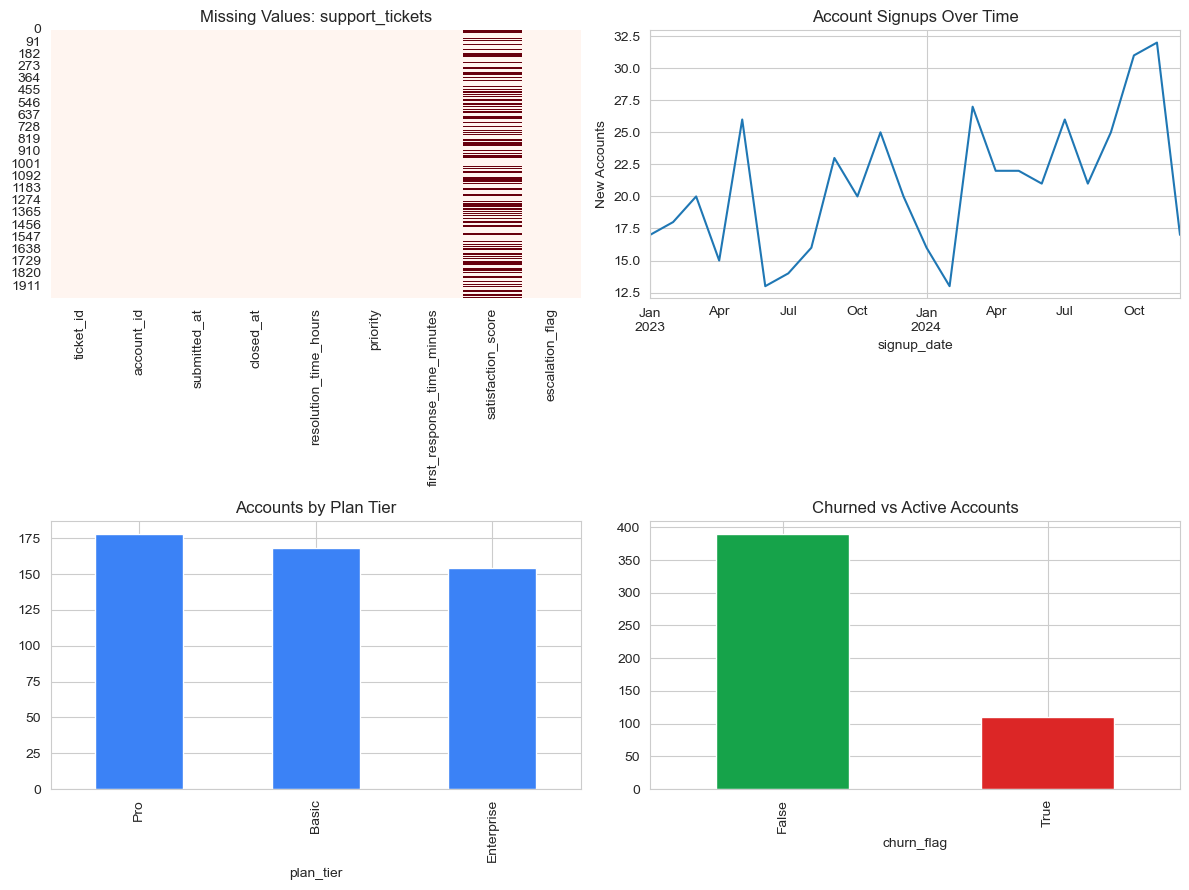

In [14]:
#Basic Visualizations

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1. Missing data heatmap — visual gut-check of where nulls cluster
sns.heatmap(support_tickets.isnull(), cbar=False, ax=axes[0,0], cmap='Reds')
axes[0,0].set_title('Missing Values: support_tickets')

# 2. Account signups over time — checks for suspicious gaps or spikes
accounts['signup_date'] = pd.to_datetime(accounts['signup_date'])
accounts.set_index('signup_date').resample('ME').size().plot(ax=axes[0,1])
axes[0,1].set_title('Account Signups Over Time')
axes[0,1].set_ylabel('New Accounts')

# 3. Plan tier distribution
accounts['plan_tier'].value_counts().plot(kind='bar', ax=axes[1,0], color='#3b82f6')
axes[1,0].set_title('Accounts by Plan Tier')

# 4. Churn flag distribution
accounts['churn_flag'].value_counts().plot(kind='bar', ax=axes[1,1], color=['#16a34a','#dc2626'])
axes[1,1].set_title('Churned vs Active Accounts')

plt.tight_layout()
plt.savefig('D:/Saas Subscription/reports/figures/phase1_data_quality_overview.png', dpi=120)
plt.show()

In [16]:
import numpy as np
import pandas as pd

engine = get_engine()
accounts = pd.read_sql("SELECT * FROM accounts", engine)

subscriptions = pd.read_sql(
    "SELECT * FROM subscriptions",
    engine
)
feature_usage = pd.read_sql(
    "SELECT * FROM feature_usage",
    engine
)
support_tickets = pd.read_sql(
    "SELECT * FROM support_tickets",
    engine
)
churn_events = pd.read_sql(
    "SELECT * FROM churn_events",
    engine
)

accounts['signup_date'] = pd.to_datetime(accounts['signup_date'])
churn_events['churn_date'] = pd.to_datetime(churn_events['churn_date'])
support_tickets['submitted_at'] = pd.to_datetime(support_tickets['submitted_at'])

print(f"accounts: {accounts.shape}, subscriptions: {subscriptions.shape}, "
      f"feature_usage: {feature_usage.shape}, support_tickets: {support_tickets.shape}, "
      f"churn_events: {churn_events.shape}")

accounts: (500, 10), subscriptions: (5000, 14), feature_usage: (25000, 9), support_tickets: (2000, 9), churn_events: (600, 9)


In [17]:
#Start the analytical table from accounts (the base grain)
customer_metrics = accounts[[
    'account_id', 'industry', 'country', 'referral_source',
    'plan_tier', 'seats', 'is_trial', 'churn_flag', 'signup_date'
]].copy()

print(customer_metrics.shape)
assert customer_metrics['account_id'].duplicated().sum() == 0, "Duplicate account_id in base table!"

(500, 9)


In [18]:
#Resolve the Account Exit Date (your earlier finding)
last_churn_date = churn_events.groupby('account_id')['churn_date'].max().rename('last_churn_date')
customer_metrics = customer_metrics.merge(last_churn_date, on='account_id', how='left')

OBS_CEILING = pd.Timestamp('2024-12-31')
unresolved_mask = (customer_metrics['churn_flag'] == 1) & (customer_metrics['last_churn_date'].isna())
print(f"Excluding {unresolved_mask.sum()} churned accounts with no resolvable churn_events date")
customer_metrics = customer_metrics[~unresolved_mask].copy()

customer_metrics['exit_or_censor_date'] = np.where(
    customer_metrics['churn_flag'] == 1, customer_metrics['last_churn_date'], OBS_CEILING
)
customer_metrics['exit_or_censor_date'] = pd.to_datetime(customer_metrics['exit_or_censor_date'])
customer_metrics['months_as_customer'] = (
    (customer_metrics['exit_or_censor_date'] - customer_metrics['signup_date']).dt.days / 30.44
).round(1)

Excluding 35 churned accounts with no resolvable churn_events date


In [19]:
# Take the churn_events row matching each account's LAST churn_date (i.e. the final exit, not an earlier reactivation cycle)
final_churn_events = churn_events.sort_values('churn_date').groupby('account_id').last().reset_index()
churn_reason_map = final_churn_events[['account_id', 'reason_code', 'refund_amount_usd']]
churn_reason_map.columns = ['account_id', 'churn_reason', 'refund_amount']

customer_metrics = customer_metrics.merge(churn_reason_map, on='account_id', how='left')

In [20]:
# Revenue Metrics
revenue_agg = subscriptions.groupby('account_id').agg(
    total_subscriptions=('subscription_id', 'count'),
    average_mrr=('mrr_amount', 'mean'),
    upgrade_count=('upgrade_flag', 'sum'),
    downgrade_count=('downgrade_flag', 'sum'),
    auto_renew_rate=('auto_renew_flag', 'mean')
).reset_index()

customer_metrics = customer_metrics.merge(revenue_agg, on='account_id', how='left')
customer_metrics['average_arr'] = (customer_metrics['average_mrr'] * 12).round(0)
customer_metrics['ltv'] = (customer_metrics['average_mrr'] * customer_metrics['months_as_customer']).round(0)

In [21]:
#Product Usage Metrics
usage_with_account = feature_usage.merge(
    subscriptions[['subscription_id', 'account_id']], on='subscription_id', how='left'
)

usage_agg = usage_with_account.groupby('account_id').agg(
    total_usage=('usage_count', 'sum'),
    average_usage=('usage_count', 'mean'),
    total_usage_duration=('usage_duration_secs', 'sum'),
    total_errors=('error_count', 'sum'),
    beta_feature_usage=('is_beta_feature', 'sum'),
    distinct_features_used=('feature_name', 'nunique')   # <-- new line
).reset_index()

customer_metrics = customer_metrics.merge(usage_agg, on='account_id', how='left')

In [22]:
#Support Metrics
support_agg = support_tickets.groupby('account_id').agg(
    total_tickets=('ticket_id', 'count'),
    average_resolution_time=('resolution_time_hours', 'mean'),
    average_first_response_time=('first_response_time_minutes', 'mean'),
    average_satisfaction_score=('satisfaction_score', 'mean'),
    escalation_rate=('escalation_flag', 'mean')
).reset_index()

customer_metrics = customer_metrics.merge(support_agg, on='account_id', how='left')

# Accounts with zero tickets get NaN here — that NaN means "never opened a ticket," a real count of zero.
customer_metrics['total_tickets'] = customer_metrics['total_tickets'].fillna(0)
customer_metrics['escalation_rate'] = customer_metrics['escalation_rate'].fillna(0)

# average_resolution_time, average_first_response_time, and average_satisfaction_score
# stay as NaN for zero-ticket accounts — there's no "average" of nothing, and filling
# with 0 would falsely claim instant resolution / perfect or terrible satisfaction.

In [23]:
#Validation Checks

print("=" * 60)
print("VALIDATION")
print("=" * 60)

print(f"\nShape: {customer_metrics.shape}")
print(f"Duplicate account_ids: {customer_metrics['account_id'].duplicated().sum()}")

print("\nMissing values:")
nulls = customer_metrics.isnull().sum()
print(nulls[nulls > 0])

# Sanity check: average_arr should always equal average_mrr * 12 exactly
arr_check = (customer_metrics['average_arr'] == (customer_metrics['average_mrr'] * 12).round(0)).all()
print(f"\naverage_arr = average_mrr * 12 holds for all rows: {arr_check}")

# Sanity check: ltv should never be negative
print(f"Negative LTV values: {(customer_metrics['ltv'] < 0).sum()}")

# Sanity check: churned accounts should have a churn_reason; active accounts generally should not
print(f"\nChurned accounts missing churn_reason: "
      f"{customer_metrics[customer_metrics['churn_flag']==1]['churn_reason'].isna().sum()}")
print(f"Active accounts WITH a churn_reason populated (reactivation signal): "
      f"{customer_metrics[customer_metrics['churn_flag']==0]['churn_reason'].notna().sum()}")

VALIDATION

Shape: (465, 32)
Duplicate account_ids: 0

Missing values:
last_churn_date                113
churn_reason                   113
refund_amount                  113
average_resolution_time          8
average_first_response_time      8
average_satisfaction_score      32
dtype: int64

average_arr = average_mrr * 12 holds for all rows: True
Negative LTV values: 0

Churned accounts missing churn_reason: 0
Active accounts WITH a churn_reason populated (reactivation signal): 277


In [24]:
print(customer_metrics.shape)
print(customer_metrics.columns.tolist())
customer_metrics.sample(5, random_state=42)

(465, 32)
['account_id', 'industry', 'country', 'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag', 'signup_date', 'last_churn_date', 'exit_or_censor_date', 'months_as_customer', 'churn_reason', 'refund_amount', 'total_subscriptions', 'average_mrr', 'upgrade_count', 'downgrade_count', 'auto_renew_rate', 'average_arr', 'ltv', 'total_usage', 'average_usage', 'total_usage_duration', 'total_errors', 'beta_feature_usage', 'distinct_features_used', 'total_tickets', 'average_resolution_time', 'average_first_response_time', 'average_satisfaction_score', 'escalation_rate']


,account_id,industry,country,referral_source,plan_tier,seats,is_trial,churn_flag,signup_date,last_churn_date,...,average_usage,total_usage_duration,total_errors,beta_feature_usage,distinct_features_used,total_tickets,average_resolution_time,average_first_response_time,average_satisfaction_score,escalation_rate
55,A-94d3da,HealthTech,US,other,Basic,41,False,False,2023-05-03,2024-04-12,...,9.666667,150051,25,5,29,6.0,26.833333,80.500000,3.5,0.0
75,A-726cfa,DevTools,US,partner,Pro,11,False,False,2023-07-01,2024-08-08,...,10.132653,281986,45,15,40,3.0,35.666667,128.333333,4.0,0.0
33,A-a45270,HealthTech,US,ads,Enterprise,3,False,False,2024-06-24,2024-11-12,...,10.323944,222582,53,4,35,4.0,64.000000,110.000000,4.0,0.0
456,A-d3c88e,DevTools,US,event,Pro,16,False,False,2024-10-18,2024-11-18,...,10.062500,204483,48,11,33,3.0,58.000000,48.000000,4.0,0.0
297,A-6a7c9d,Cybersecurity,US,organic,Enterprise,26,False,True,2024-10-24,2024-11-21,...,9.947368,65006,6,1,15,3.0,34.333333,60.000000,4.0,0.0


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

cm = customer_metrics.copy()  # short alias, less typing

plan_tier
Pro           165
Basic         155
Enterprise    145
Name: count, dtype: int64
industry
DevTools         106
FinTech          100
Cybersecurity     95
HealthTech        88
EdTech            76
Name: count, dtype: int64


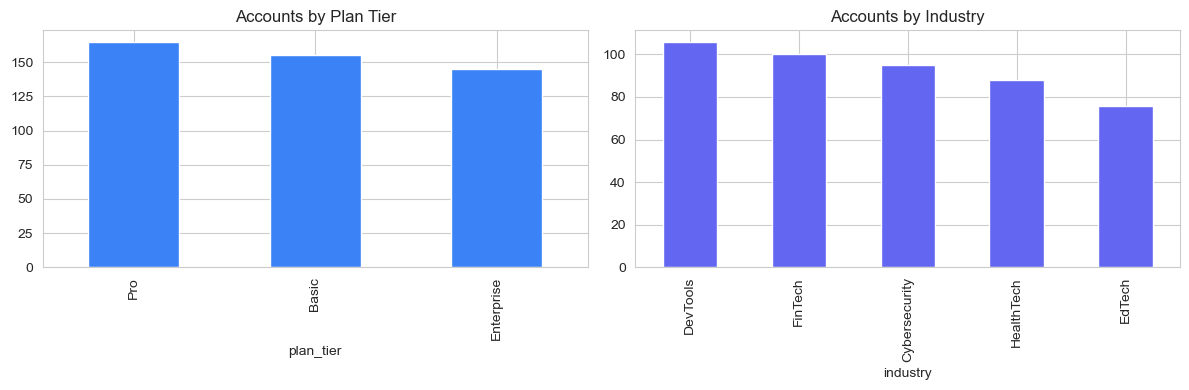

In [26]:
#Customer Distribution

print(cm['plan_tier'].value_counts())
print(cm['industry'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm['plan_tier'].value_counts().plot(kind='bar', ax=axes[0], color='#3b82f6', title='Accounts by Plan Tier')
cm['industry'].value_counts().plot(kind='bar', ax=axes[1], color='#6366f1', title='Accounts by Industry')
plt.tight_layout()
plt.show()

Churn rate: 16.1%  |  Retention rate: 83.9%


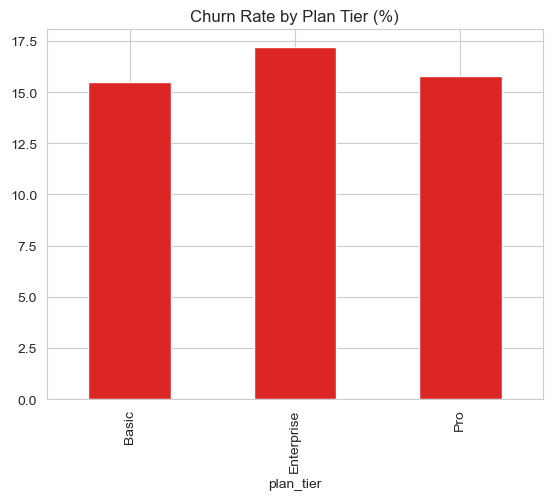

In [27]:
#Churn Rate & Retention Rate

churn_rate = cm['churn_flag'].mean() * 100
retention_rate = 100 - churn_rate
print(f"Churn rate: {churn_rate:.1f}%  |  Retention rate: {retention_rate:.1f}%")

cm.groupby('plan_tier')['churn_flag'].mean().mul(100).round(1).plot(
    kind='bar', color='#dc2626', title='Churn Rate by Plan Tier (%)')
plt.show()

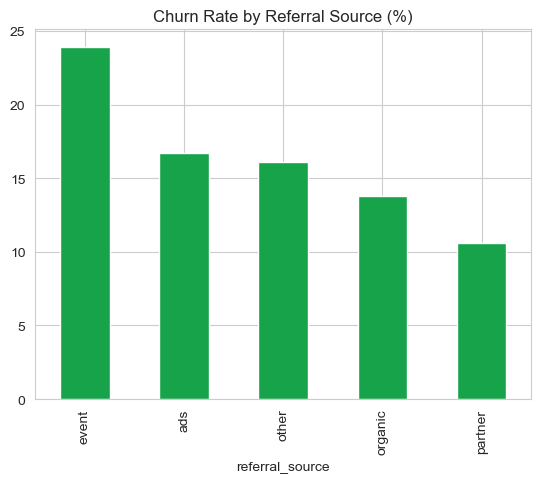

In [28]:
#Referral Source Analysis

cm.groupby('referral_source')['churn_flag'].mean().mul(100).round(1) \
  .sort_values(ascending=False).plot(kind='bar', color='#16a34a', title='Churn Rate by Referral Source (%)')
plt.show()

Total MRR: $1,067,536  |  ARR: $12,810,438  |  ARPA: $2,296


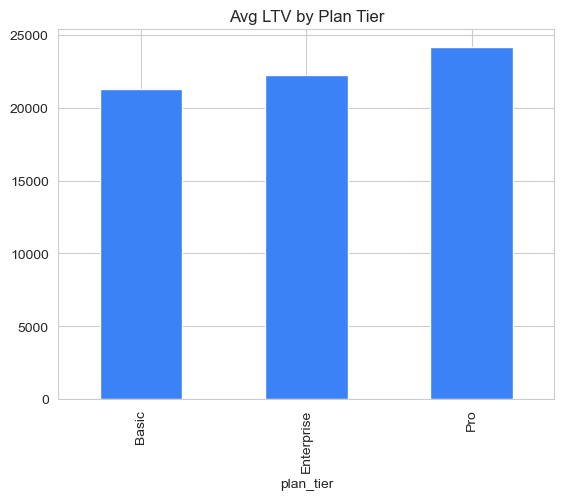

In [29]:
#Revenue: MRR, ARR, ARPA

mrr_total = cm['average_mrr'].sum()
arpa = cm['average_mrr'].mean()  # Average Revenue Per Account
print(f"Total MRR: ${mrr_total:,.0f}  |  ARR: ${mrr_total*12:,.0f}  |  ARPA: ${arpa:,.0f}")

cm.groupby('plan_tier')['ltv'].mean().round(0).plot(kind='bar', color='#3b82f6', title='Avg LTV by Plan Tier')
plt.show()

In [30]:
 #Support Analysis

print(cm.groupby('churn_flag')[['average_satisfaction_score','escalation_rate']].mean().round(2))

            average_satisfaction_score  escalation_rate
churn_flag                                             
False                             3.95             0.04
True                              3.95             0.06


In [31]:
print(cm.groupby('churn_flag')[['total_usage','distinct_features_used']].mean().round(1))

            total_usage  distinct_features_used
churn_flag                                     
False             495.1                    27.4
True              504.9                    27.8


In [32]:
cm.to_csv('customer_metrics_for_powerbi.csv', index=False)
print("Saved. Import this single CSV as your Power BI data source.")

Saved. Import this single CSV as your Power BI data source.
